In [1]:
#Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load Dataset
import os

path = r"C:\Users\USER\Downloads\train.csv"

print("Exists:", os.path.exists(path))
print("Is file:", os.path.isfile(path))

Exists: True
Is file: False


In [3]:
import os

path = r"C:\Users\USER\Downloads\train.csv"

print(os.path.isdir(path))
print(os.path.isfile(path))

True
False


In [4]:
df = pd.read_csv(r"C:\Users\USER\Downloads\train.csv\train.csv")

In [5]:
import os

path = r"C:\Users\USER\Downloads\train.csv"

for item in os.listdir(path):
    print(item)

train.csv


In [8]:
df.shape

(9800, 18)

In [6]:
#Inspect the dataset
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (9800, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680



Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region   

In [7]:
#Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
#In Calculate The Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [10]:
#In for numeric column
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())
print(numeric_columns)

Index(['Row ID', 'Postal Code', 'Sales'], dtype='object')


In [13]:
#Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])
print(categorical_columns)
print(df.isnull().sum())

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [14]:
#Chaeck duplicates 
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [17]:
#Correct Date colums
print(df.dtypes)


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [20]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)
print(df[['Order Date', 'Ship Date']].head())
print(df[['Order Date', 'Ship Date']].dtypes)

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [22]:
#Use In Statistics
# Statistical Analysis

print("Statistical Summary:")
display(df[['Sales']].describe())

print("\nMean Sales:")
print(df['Sales'].mean())

print("\nMedian Sales:")
print(df['Sales'].median())

print("\nStandard Deviation of Sales:")
print(df['Sales'].std())

Statistical Summary:


,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000



Mean Sales:
230.7690594591837

Median Sales:
54.489999999999995

Standard Deviation of Sales:
626.6518748388047


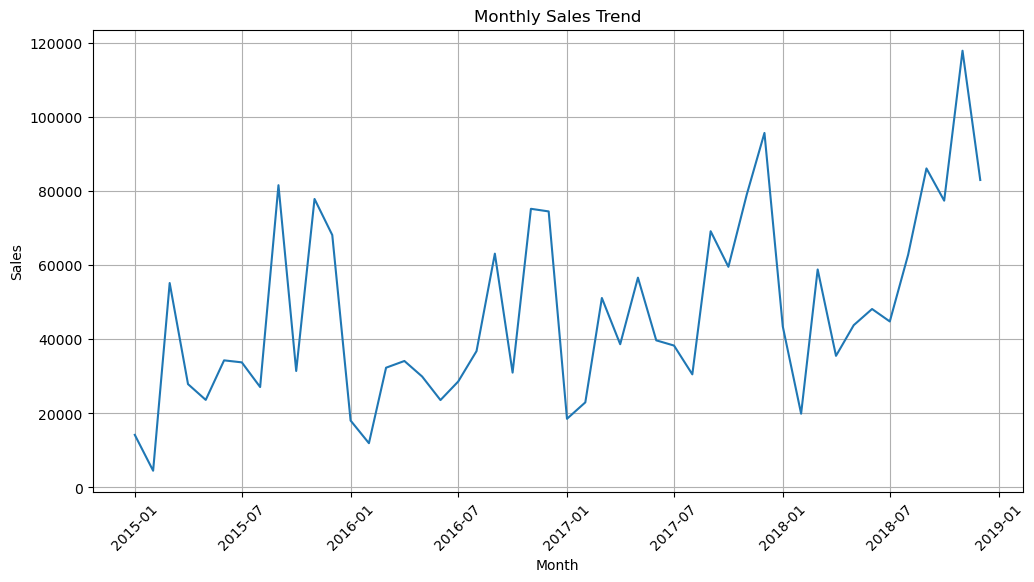

In [23]:
#To perform the EDA
#sTEP:-  Sales Treand over the Time
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid()
plt.show()

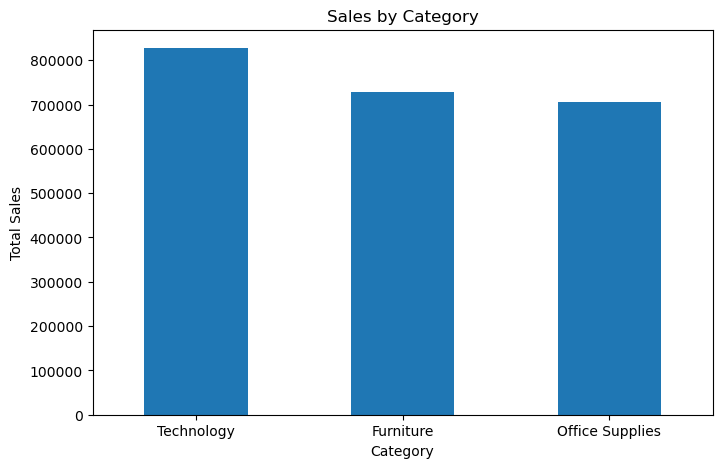

In [24]:
#Step:2 Category-wise Revenue
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

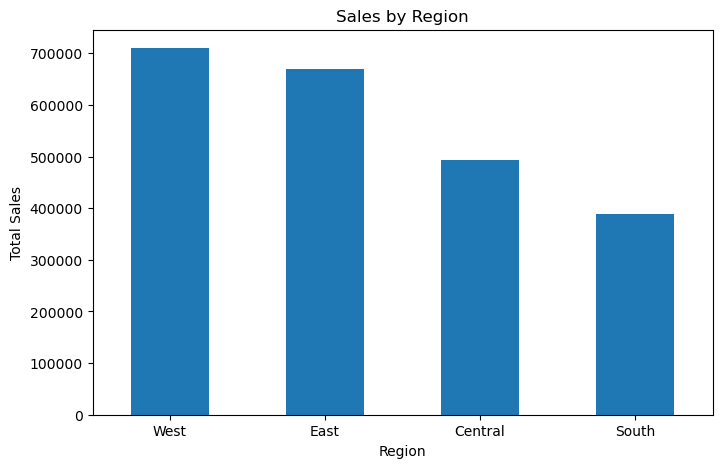

In [25]:
#Step :3 Region-wise Performance
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

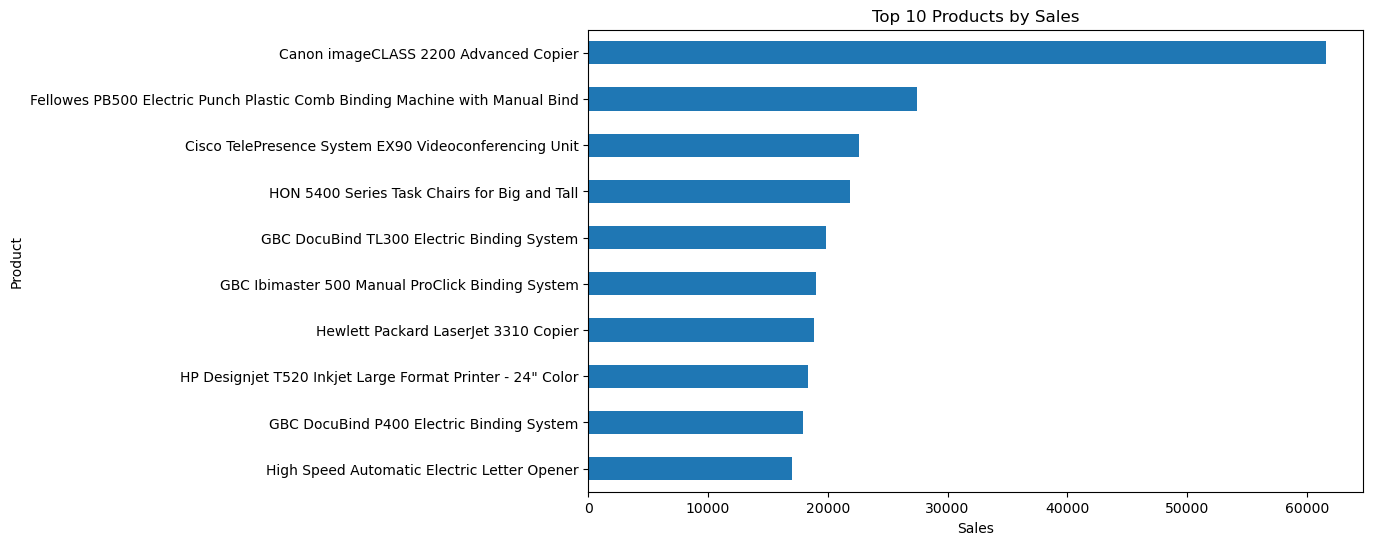

In [26]:
#Step:-4 Top 10 Products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

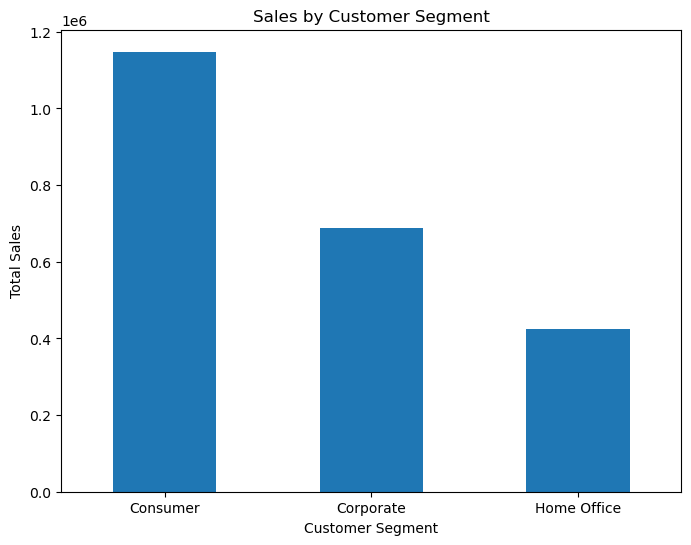

In [29]:
# Step 4 - Sales by Customer Segment

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))

segment_sales.plot(kind='bar')

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

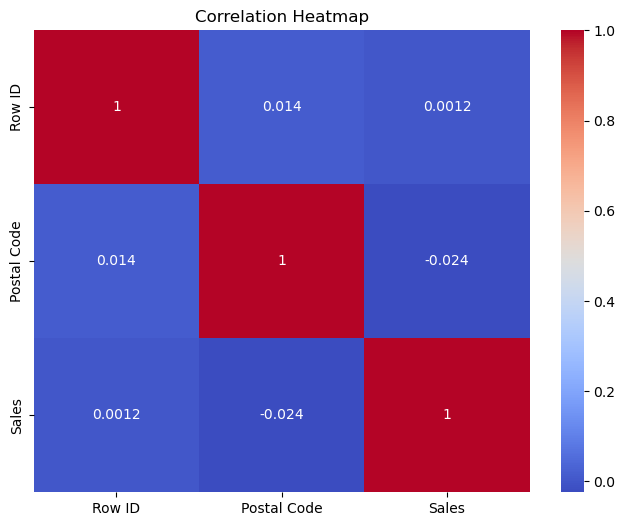

In [30]:
#Step :-5 Correlation Heatmap
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [31]:
# To Build The Machine Learning Model
#Prepare monthly sales data
monthly = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

monthly['Order Date'] = monthly['Order Date'].dt.to_timestamp()

monthly['Month_Number'] = np.arange(len(monthly))

display(monthly.head())


,Order Date,Sales,Month_Number
0,2015-01-01,14205.707,0
1,2015-02-01,4519.892,1
2,2015-03-01,55205.797,2
3,2015-04-01,27906.855,3
4,2015-05-01,23644.303,4


In [36]:
#Creates X and Y
X = monthly[['Month_Number']]
Y = monthly['Sales']
print(X, Y)

    Month_Number
0              0
1              1
2              2
3              3
4              4
5              5
6              6
7              7
8              8
9              9
10            10
11            11
12            12
13            13
14            14
15            15
16            16
17            17
18            18
19            19
20            20
21            21
22            22
23            23
24            24
25            25
26            26
27            27
28            28
29            29
30            30
31            31
32            32
33            33
34            34
35            35
36            36
37            37
38            38
39            39
40            40
41            41
42            42
43            43
44            44
45            45
46            46
47            47 0      14205.7070
1       4519.8920
2      55205.7970
3      27906.8550
4      23644.3030
5      34322.9356
6      33781.5430
7      27117.5365
8      81623.5268
9    

In [38]:
#Split The Data
split_point = int(len(monthly) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]
print(split_point)

38


In [42]:
#Train Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = model.predict(X_test)

In [44]:
#Evalute The Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 23619.289223453263
R² Score: 0.03323365449775528


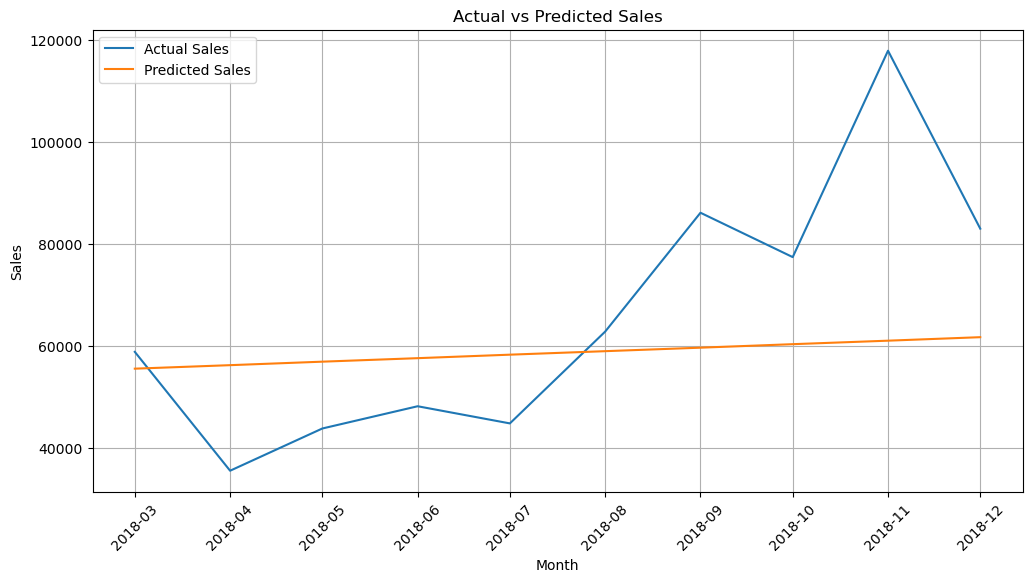

In [45]:
#Creates The Model Evalution Chart
plt.figure(figsize=(12,6))

plt.plot(
    monthly['Order Date'].iloc[split_point:],
    y_test,
    label='Actual Sales'
)

plt.plot(
    monthly['Order Date'].iloc[split_point:],
    y_pred,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [48]:
# Forecast next 6 months

future_months = np.arange(
    len(monthly),
    len(monthly) + 6
).reshape(-1, 1)

future_predictions = model.predict(future_months)

last_date = monthly['Order Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq='MS'
)

forecast = pd.DataFrame({
    'Month': future_dates,
    'Forecasted Sales': future_predictions
})

print("Future Sales Forecast:")
display(forecast)

Future Sales Forecast:


,Month,Forecasted Sales
0,2019-01-01,62426.416513
1,2019-02-01,63112.698041
2,2019-03-01,63798.979569
3,2019-04-01,64485.261097
4,2019-05-01,65171.542624
5,2019-06-01,65857.824152
